<a href="https://colab.research.google.com/github/yoshimabudiman-spec/emnist_cnn_model/blob/main/testing_platform.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Library

In [1]:
# Run this in Google Colab (Runtime > Change runtime type > GPU)
import os
from google.colab import drive
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
from keras.callbacks import LearningRateScheduler
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
from PIL import Image
import io

print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TF version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Checking for Data Leakage (Overlap between Training and Test Data)

It's crucial to ensure that there is no overlap between the training and test datasets. If a model is tested on data it has already seen during training, its reported accuracy will be artificially inflated and won't reflect its true generalization ability. We'll perform a check to see if any images from `x_test` are also present in `x_train`.

### Loading a Pre-trained EMNIST Model (.h5)

In [9]:
# Define the base path for your model in Google Drive
drive_path = '/content/drive/MyDrive/'
ensemble = []
model_filename = 'emnist_cnn_microresnet_fixed.h5' # Corrected to your file name
model_path = os.path.join(drive_path, model_filename)

try:
    model = tf.keras.models.load_model(model_path)
    ensemble.append(model)
    print(f"Successfully loaded model from {model_path}")
except Exception as e:
    print(f"Error loading model from {model_path}: {e}")
    print("Please ensure the .h5 model file exists and is accessible in your Google Drive.")

print(f"Total models loaded into ensemble: {len(ensemble)}")

Successfully loaded model from /content/drive/MyDrive/emnist_cnn_microresnet_fixed.h5
Total models loaded into ensemble: 1


# Load Your Image

Please upload an image of a single digit (preferably 28x28 grayscale).


<IPython.core.display.Javascript object>

Image uploaded successfully to memory.


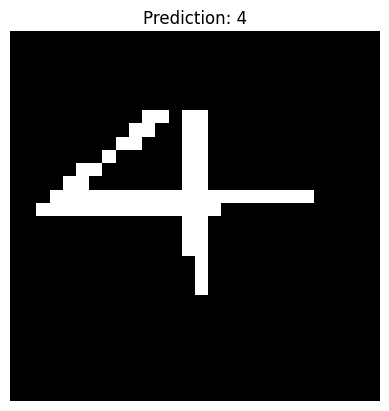

In [38]:
# Install pillow_heif for HEIC support if not already installed
try:
    import pillow_heif
except ImportError:
    print("Installing pillow_heif for HEIC support...")
    !pip install pillow_heif
    import pillow_heif

def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename

def upload_photo():
  js = Javascript('''
    async function uploadPhoto() {
      const fileInput = document.createElement('input');
      fileInput.type = 'file';
      fileInput.accept = 'image/*';

      const div = document.createElement('div');
      const uploadBtn = document.createElement('button');
      div.appendChild(fileInput);
      document.body.appendChild(div);

      await new Promise(resolve => {
        uploadBtn.onclick = () => fileInput.click();
        fileInput.onchange = resolve;
      });

      const file = fileInput.files[0];
      const reader = new FileReader();
      reader.readAsDataURL(file);

      await new Promise(resolve => reader.onload = resolve);
      div.remove();
      return { data: reader.result, name: file.name };
    }
    ''')
  display(js)
  result = eval_js('uploadPhoto()')
  data = result['data']

  binary_data = b64decode(data.split(',')[1])
  return binary_data # Return binary data directly

# Upload an image file
print("Please upload an image of a single digit (preferably 28x28 grayscale).")
try:
  # image_data now holds the binary content, not a filename
  image_data = upload_photo()
  print('Image uploaded successfully to memory.')
except Exception as err:
  print(str(err))
  print('Failed to upload image. Please try again.')
  image_data = None


if image_data:
    try:
        # Load the image from binary data using io.BytesIO
        img = Image.open(io.BytesIO(image_data))

        # Convert to grayscale if not already
        if img.mode != 'L':
            img = img.convert('L')

        # Resize to 28x28
        img = img.resize((28, 28), Image.LANCZOS)

        # Convert to numpy array and normalize
        img_array = np.array(img).astype('float32') / 255.0

        # Invert colors if necessary (MNIST has white digit on black background)
        img_array = 1.0 - img_array

        # Reshape for model input (batch_size, height, width, channels)
        img_input = img_array.reshape(1, 28, 28, 1)

        # Make prediction with the ensemble
        if 'ensemble' in globals() and ensemble:
            # Define the class labels for EMNIST (digits 0-9, then uppercase A-Z)
            emnist_labels = '0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ'

            # Initialize ensemble_probs for 36 classes
            ensemble_probs = np.zeros((1, 36))
            for model in ensemble:
                ensemble_probs += model.predict(img_input, verbose=0)
            ensemble_probs /= len(ensemble)

            predicted_index = np.argmax(ensemble_probs)
            predicted_char = emnist_labels[predicted_index]

            # Display the image and prediction
            plt.imshow(img_array, cmap='gray')
            plt.title(f"Prediction: {predicted_char}")
            plt.axis('off')
            plt.show()
        else:
            print("Error: 'ensemble' model not found. Please ensure the model loading cells were executed.")

    except Exception as e:
        print(f"An error occurred during image processing or prediction: {e}")
else:
    print("No image was loaded for prediction.")